# 🚗 Customer Purchase Prediction Using AI

## Capstone Project

### Business Case Study
**Market Entry Analysis for ABG Motors in India**

---

### 👨‍🎓 Submitted By
DASARI SANDEEP

### 🏫 Course
Data Science with Artificial Intelligence

---

## 📌 Project Objective

The objective of this project is to predict potential customers who are likely to purchase a new vehicle in the Indian market using historical Japanese customer data.

The complete project is developed using:

- Pandas
- NumPy
- Matplotlib
- Seaborn

The Logistic Regression algorithm is implemented from scratch using NumPy.

# 📚 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 Load Datasets

In [2]:
jpn = pd.read_csv("JPN_DATA.csv")
ind = pd.read_csv("IN_DATA.csv")

# 🔍 Data Understanding

In [3]:
jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,"445,344",439,0
1,00003I71CQ,35,M,"107,634",283,0
2,00003N47FS,59,F,"502,787",390,1
3,00005H41DE,43,M,"585,664",475,0
4,00007E17UM,39,F,"705,723",497,1


In [4]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,"1,425,390",4/20/2018
1,89602T51HX,47,M,"1,678,954",6/8/2018
2,70190Z52IP,60,M,"931,624",7/31/2017
3,25623V15MU,55,F,"1,106,320",7/31/2017
4,36230I68CE,32,F,"748,465",1/27/2019


In [5]:
print(jpn.shape)
print(ind.shape)

(40000, 6)
(70000, 5)


In [6]:
print(jpn.columns)

Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE'], dtype='object')


In [7]:
print(ind.columns)

Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT'], dtype='object')


In [8]:
jpn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          40000 non-null  object
 1   CURR_AGE    40000 non-null  int64 
 2   GENDER      40000 non-null  object
 3   ANN_INCOME  40000 non-null  object
 4   AGE_CAR     40000 non-null  int64 
 5   PURCHASE    40000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 1.8+ MB


In [9]:
ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          70000 non-null  object
 1   CURR_AGE    70000 non-null  int64 
 2   GENDER      70000 non-null  object
 3   ANN_INCOME  70000 non-null  object
 4   DT_MAINT    70000 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.7+ MB


# 🧹 Data Cleaning

In [10]:
jpn.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

In [11]:
ind.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
dtype: int64

In [12]:
jpn.duplicated().sum()

np.int64(0)

In [13]:
ind.duplicated().sum()

np.int64(0)

# 📊 Exploratory Data Analysis (EDA)

In [14]:
jpn.describe()

,CURR_AGE,AGE_CAR,PURCHASE
count,40000.00000,40000.000000,40000.000000
mean,44.99745,359.080250,0.575775
std,11.82008,203.063724,0.494231
min,25.00000,1.000000,0.000000
25%,35.00000,235.000000,0.000000
50%,45.00000,331.000000,1.000000
75%,55.00000,444.000000,1.000000
max,65.00000,1020.000000,1.000000


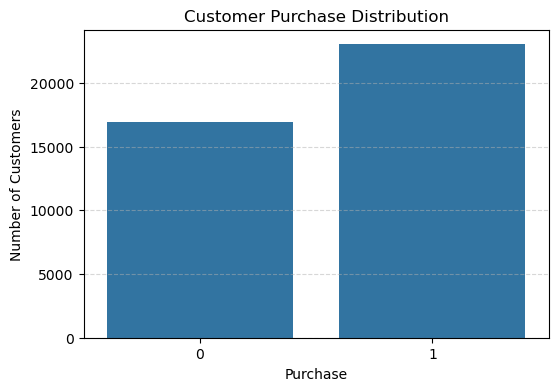

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="PURCHASE", data=jpn)
plt.title("Customer Purchase Distribution")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [16]:
ind.describe()

,CURR_AGE
count,70000.000000
mean,44.995314
std,11.822122
min,25.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,65.000000


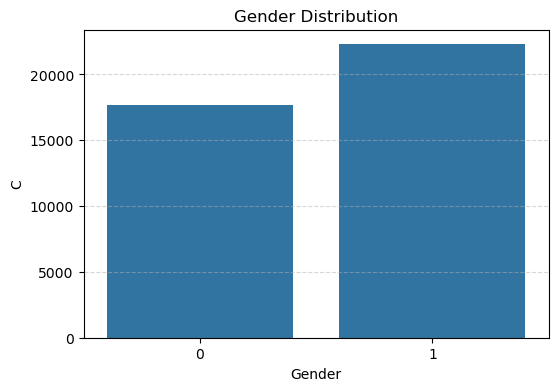

In [88]:
plt.figure(figsize=(6,4))
sns.countplot(x="GENDER", data=jpn)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("C")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [18]:
jpn["GENDER"].unique()

array(['M', 'F'], dtype=object)

In [19]:
ind["GENDER"].unique()

array(['M', 'F'], dtype=object)

In [20]:
jpn["PURCHASE"].value_counts()

PURCHASE
1    23031
0    16969
Name: count, dtype: int64

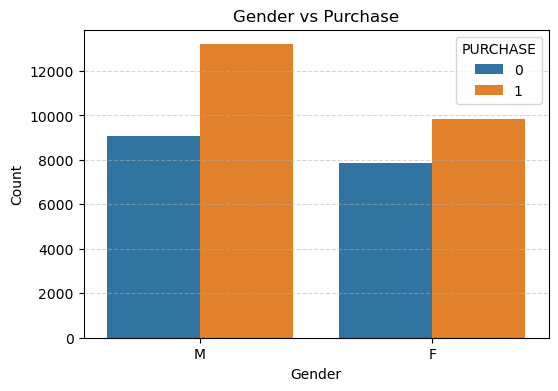

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="GENDER", hue="PURCHASE", data=jpn)
plt.title("Gender vs Purchase")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [22]:
jpn.dtypes

ID            object
CURR_AGE       int64
GENDER        object
ANN_INCOME    object
AGE_CAR        int64
PURCHASE       int64
dtype: object

In [23]:
ind.dtypes

ID            object
CURR_AGE       int64
GENDER        object
ANN_INCOME    object
DT_MAINT      object
dtype: object

In [24]:
jpn["ANN_INCOME"] = jpn["ANN_INCOME"].str.replace(",","")
jpn["ANN_INCOME"] = jpn["ANN_INCOME"].astype(int)

In [25]:
ind["ANN_INCOME"] = ind["ANN_INCOME"].str.replace(",","")
ind["ANN_INCOME"] = ind["ANN_INCOME"].astype(int)

In [26]:
jpn.dtypes

ID            object
CURR_AGE       int64
GENDER        object
ANN_INCOME     int64
AGE_CAR        int64
PURCHASE       int64
dtype: object

In [27]:
ind.dtypes

ID            object
CURR_AGE       int64
GENDER        object
ANN_INCOME     int64
DT_MAINT      object
dtype: object

In [28]:
jpn["GENDER"] = jpn["GENDER"].map({
    "M": 1,
    "F": 0
})

ind["GENDER"] = ind["GENDER"].map({
    "M": 1,
    "F": 0
})

In [29]:
jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,1,445344,439,0
1,00003I71CQ,35,1,107634,283,0
2,00003N47FS,59,0,502787,390,1
3,00005H41DE,43,1,585664,475,0
4,00007E17UM,39,0,705723,497,1


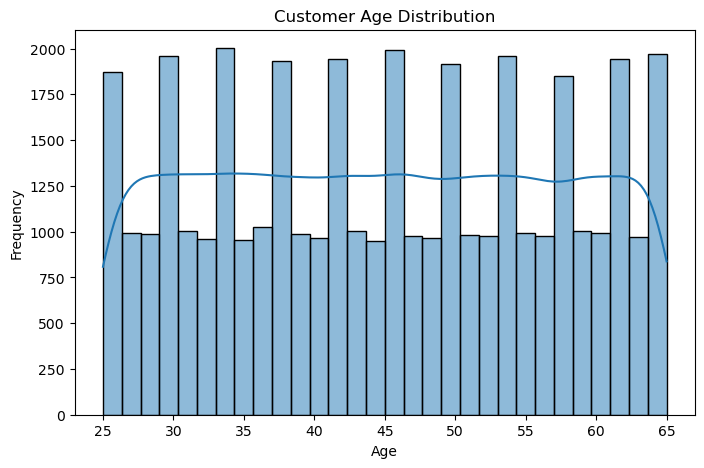

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(jpn["CURR_AGE"], bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [31]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,1,1425390,4/20/2018
1,89602T51HX,47,1,1678954,6/8/2018
2,70190Z52IP,60,1,931624,7/31/2017
3,25623V15MU,55,0,1106320,7/31/2017
4,36230I68CE,32,0,748465,1/27/2019


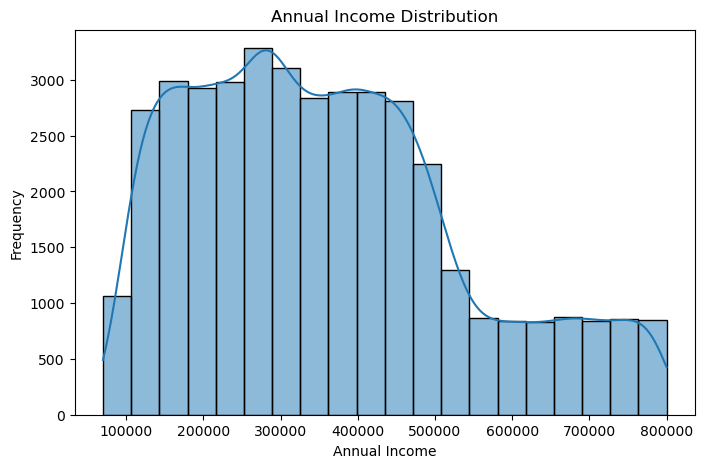

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(jpn["ANN_INCOME"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

In [33]:
x = jpn.drop(["ID", "PURCHASE"], axis=1)
y = jpn["PURCHASE"]

In [34]:
x.head()

,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR
0,50,1,445344,439
1,35,1,107634,283
2,59,0,502787,390
3,43,1,585664,475
4,39,0,705723,497


In [35]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: PURCHASE, dtype: int64

In [36]:
print(x.shape)
print(y.shape)

(40000, 4)
(40000,)


In [37]:
 x.describe()

,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR
count,40000.00000,40000.000000,40000.000000,40000.000000
mean,44.99745,0.557125,359398.878225,359.080250
std,11.82008,0.496732,175109.260472,203.063724
min,25.00000,0.000000,70089.000000,1.000000
25%,35.00000,0.000000,219766.000000,235.000000
50%,45.00000,1.000000,337657.000000,331.000000
75%,55.00000,1.000000,464260.750000,444.000000
max,65.00000,1.000000,799971.000000,1020.000000


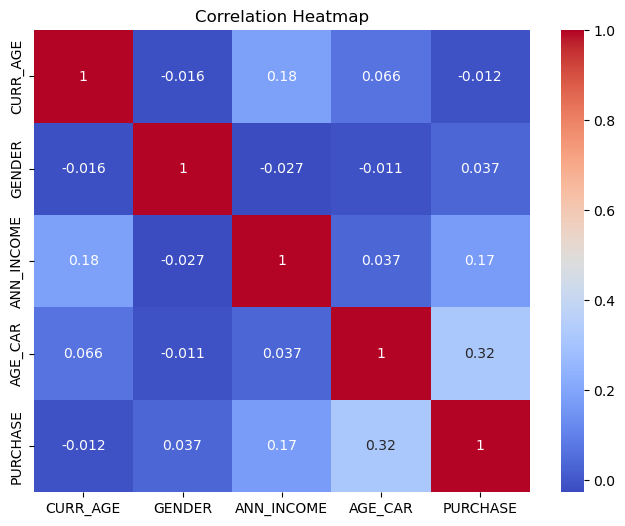

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(jpn.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [39]:
x = (x - np.mean(x, axis=0)) / np.std(x, axis=0)

In [40]:
x = np.c_[np.ones(x.shape[0]), x]

In [41]:
print(x.shape)

(40000, 5)


In [42]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [43]:
print(sigmoid(0))

0.5


In [44]:
weights = np.zeros(x.shape[1])

In [45]:
print(weights)

[0. 0. 0. 0. 0.]


In [46]:
z = np.dot(x, weights)
predictions = sigmoid(z)
print(predictions[:10])

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [47]:
def compute_cost(x, y, weights):
    m = len(y)
    predictions = sigmoid(np.dot(x, weights))
    cost = -(1/m) * np.sum(
    y * np.log(predictions + 1e-10) +
    (1-y) * np.log(1-predictions + 1e-10)
    )

    return cost

In [48]:
cost = compute_cost(x, y, weights)
print(cost)

0.6931471803599453


In [49]:
def gradient_descent(x, y, weights, learning_rate, iterations):

    m = len(y)
    cost_history = []

    for i in range(iterations):
        predictions = sigmoid(np.dot(x, weights))
        gradient = (1/m) * np.dot(x.T, (predictions - y))
        weights = weights - learning_rate * gradient
        cost = compute_cost(x, y, weights)
        cost_history.append(cost)
    return weights, cost_history

In [50]:
learning_rate = 0.01
iterations = 1000

In [51]:
weights, cost_history = gradient_descent(
    x,
    y,
    weights,
    learning_rate,
    iterations
)

In [52]:
print(cost_history[-1])

0.6084419436314507


In [53]:
print(weights)

[ 0.30927009 -0.09296126  0.08547434  0.33359108  0.65346224]


In [54]:
def predict(x, weights):
    probabilities = sigmoid(np.dot(x, weights))
    predictions = (probabilities >= 0.5).astype(int)
    return predictions

In [55]:
y_pred = predict(x, weights)

In [56]:
accuracy = np.mean(y_pred == y) * 100
print("Accuracy:", accuracy)

Accuracy: 67.47


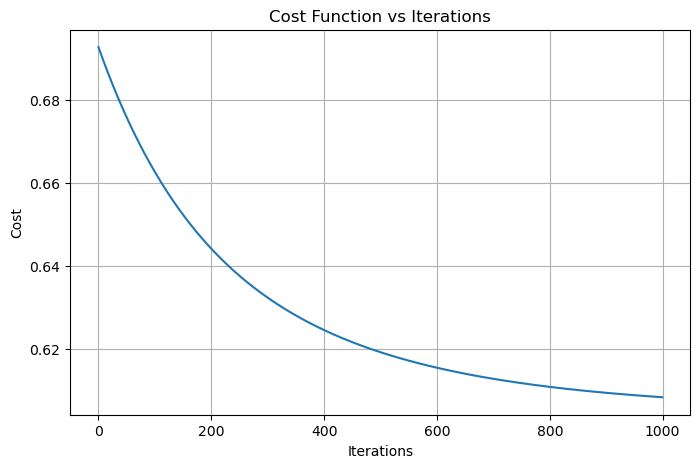

In [57]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [58]:
print(y_pred[:20])

[1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 1 1]


In [59]:
print(y[:20].values)

[0 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 0 0 1 1]


In [60]:
ind.columns

Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT'], dtype='object')

In [61]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,1,1425390,4/20/2018
1,89602T51HX,47,1,1678954,6/8/2018
2,70190Z52IP,60,1,931624,7/31/2017
3,25623V15MU,55,0,1106320,7/31/2017
4,36230I68CE,32,0,748465,1/27/2019


In [62]:
ind["DT_MAINT"] = pd.to_datetime(ind["DT_MAINT"])

In [63]:
current_year = 2025

ind["AGE_CAR"] = current_year - ind["DT_MAINT"].dt.year

In [64]:
ind = ind.drop("DT_MAINT", axis=1)

In [65]:
x_ind = ind.drop(["ID", "PREDICTED_PURCHSE"], axis = 1, errors="ignore")

In [66]:
x_ind.columns

Index(['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR'], dtype='object')

In [67]:
x_ind.head()

,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR
0,54,1,1425390,7
1,47,1,1678954,7
2,60,1,931624,8
3,55,0,1106320,8
4,32,0,748465,6


In [68]:
x_ind = ind[["CURR_AGE", "GENDER", "ANN_INCOME", "AGE_CAR"]]

In [69]:
train_features = jpn[["CURR_AGE", "GENDER", "ANN_INCOME", "AGE_CAR"]]

mean = np.mean(train_features.values, axis=0)
std = np.std(train_features.values, axis=0)

x_ind = (x_ind - mean) / std

In [70]:
x_ind = np.c_[np.ones(x_ind.shape[0]), x_ind]

In [71]:
ind_predictions = predict(x_ind, weights)

In [72]:
ind["PREDICTED_PURCHASE"] = ind_predictions

In [73]:
print(ind["PREDICTED_PURCHASE"].value_counts())

PREDICTED_PURCHASE
1    56303
0    13697
Name: count, dtype: int64


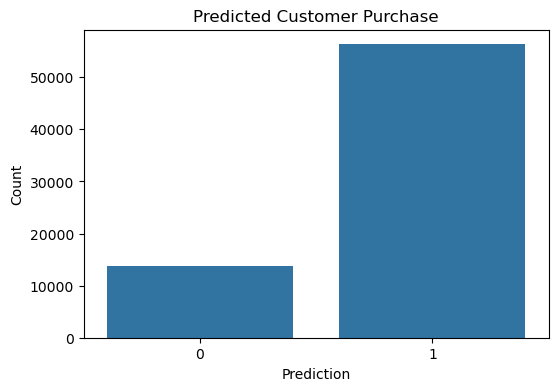

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x="PREDICTED_PURCHASE", data=ind)
plt.title("Predicted Customer Purchase")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()

In [75]:
ind_predictions = predict(x_ind, weights)

In [76]:
ind["PREDICTED_PURCHASE"] = ind_predictions

In [77]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PREDICTED_PURCHASE
0,20710B05XL,54,1,1425390,7,1
1,89602T51HX,47,1,1678954,7,1
2,70190Z52IP,60,1,931624,8,1
3,25623V15MU,55,0,1106320,8,1
4,36230I68CE,32,0,748465,6,0


In [78]:
ind["PREDICTED_PURCHASE"].value_counts()

PREDICTED_PURCHASE
1    56303
0    13697
Name: count, dtype: int64

In [79]:
potential_customers = ind[ind["PREDICTED_PURCHASE"] == 1]

In [80]:
potential_customers.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PREDICTED_PURCHASE
0,20710B05XL,54,1,1425390,7,1
1,89602T51HX,47,1,1678954,7,1
2,70190Z52IP,60,1,931624,8,1
3,25623V15MU,55,0,1106320,8,1
5,11264G01HZ,48,0,1051927,7,1


In [81]:
print("Total Potential Customers:", len(potential_customers))

Total Potential Customers: 56303


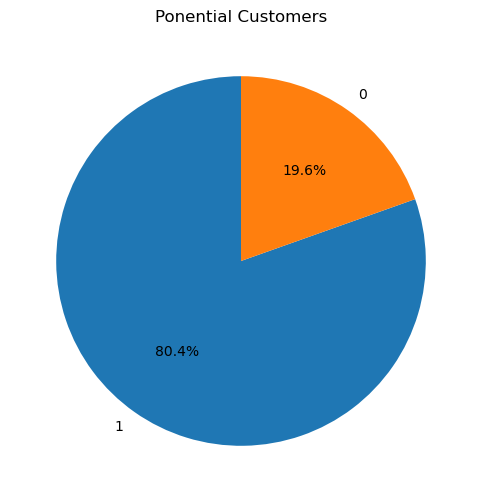

In [82]:
plt.figure(figsize=(6,6))
ind["PREDICTED_PURCHASE"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Ponential Customers")
plt.ylabel("")
plt.show()

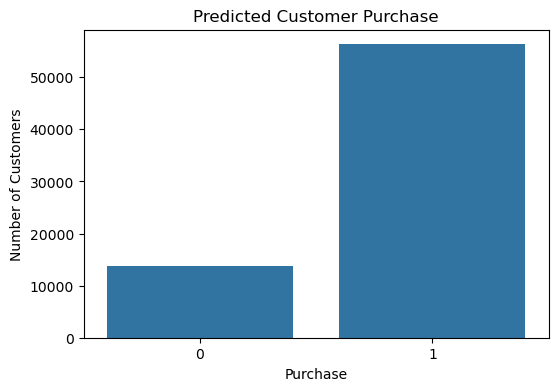

In [83]:
plt.figure(figsize=(6,4))
sns.countplot(x="PREDICTED_PURCHASE", data=ind)
plt.title("Predicted Customer Purchase")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")
plt.show()

In [84]:
potential_customers.to_csv("Potential_Customers.csv", index=False)

print("File Saved Successfully!")

File Saved Successfully!


In [85]:
print("="*45)
print("CUSTOMER PURCHASE PREDICTION REPORT")
print("="*45)
print("Training Accuracy       :", round(accuracy,2), "%")
print("Total Customers         :", len(ind))
print("Potential Customers     :", len(potential_customers))
print("Non Potential Customers :", len(ind)-len(potential_customers))
print("="*45)

CUSTOMER PURCHASE PREDICTION REPORT
Training Accuracy       : 67.47 %
Total Customers         : 70000
Potential Customers     : 56303
Non Potential Customers : 13697


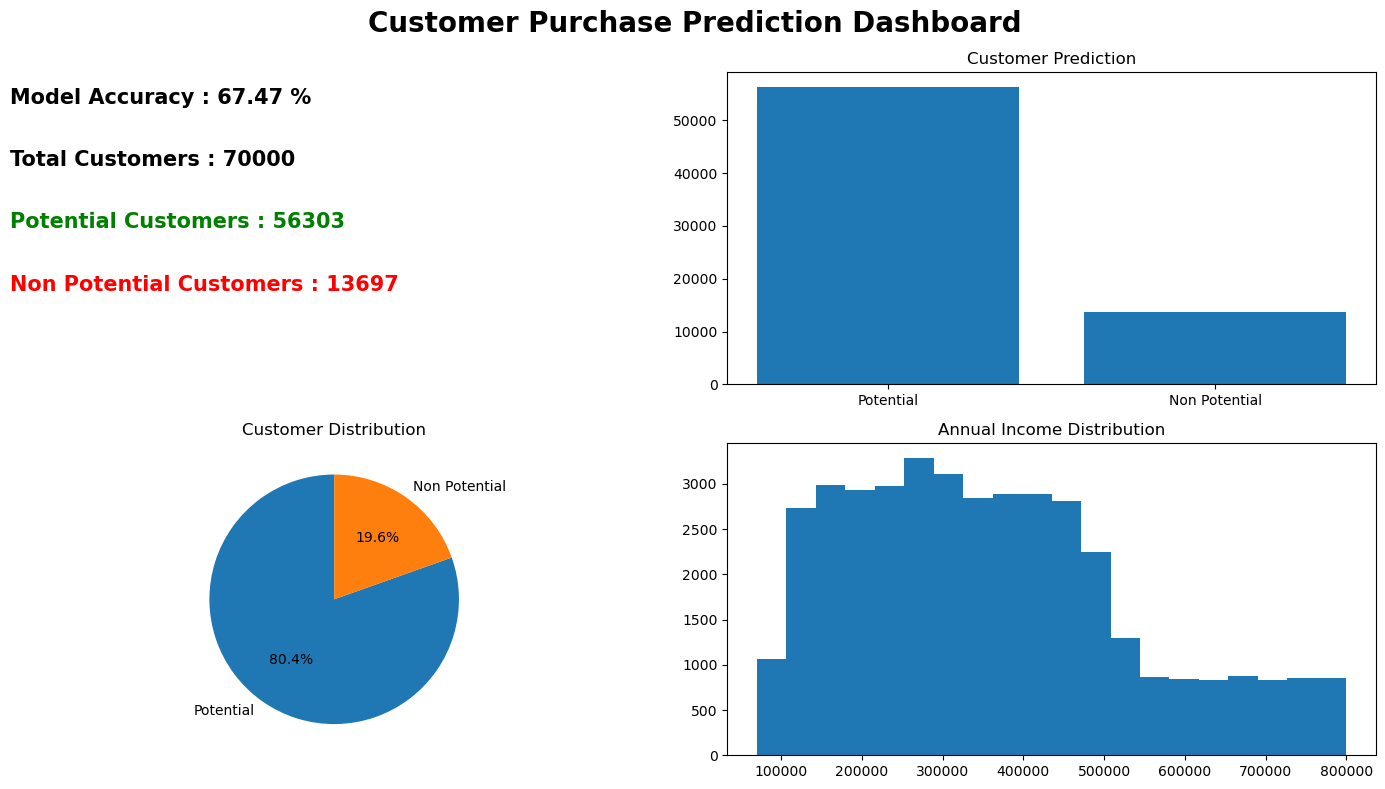

In [86]:
import matplotlib.pyplot as plt

buyers = len(potential_customers)
non_buyers = len(ind) - buyers

fig = plt.figure(figsize=(14,8))
fig.suptitle("Customer Purchase Prediction Dashboard",
             fontsize=20,
             fontweight='bold')

# ---------------- KPI ----------------

plt.subplot(2,2,1)
plt.axis('off')

plt.text(0,0.90,f"Model Accuracy : {accuracy:.2f} %",
         fontsize=15,
         weight='bold')

plt.text(0,0.70,f"Total Customers : {len(ind)}",
         fontsize=15,
         weight='bold')

plt.text(0,0.50,f"Potential Customers : {buyers}",
         fontsize=15,
         weight='bold',
         color='green')

plt.text(0,0.30,f"Non Potential Customers : {non_buyers}",
         fontsize=15,
         weight='bold',
         color='red')

# ---------------- Bar Chart ----------------

plt.subplot(2,2,2)

plt.bar(
    ["Potential","Non Potential"],
    [buyers,non_buyers]
)

plt.title("Customer Prediction")

# ---------------- Pie Chart ----------------

plt.subplot(2,2,3)

plt.pie(
    [buyers,non_buyers],
    labels=["Potential","Non Potential"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution")

# ---------------- Histogram ----------------

plt.subplot(2,2,4)

plt.hist(
    jpn["ANN_INCOME"],
    bins=20
)

plt.title("Annual Income Distribution")

plt.tight_layout()

plt.show()

# ✅ Conclusion

This project successfully developed a Customer Purchase Prediction model for ABG Motors using historical Japanese customer data. The complete workflow included data loading, data cleaning, exploratory data analysis (EDA), feature engineering, model building, and prediction.

The Logistic Regression algorithm was implemented from scratch using NumPy. Pandas was used for data manipulation, while Matplotlib and Seaborn were used to visualize customer behavior and market trends.

The trained model was then applied to the Indian customer dataset to identify potential customers who are more likely to purchase a new vehicle. These predictions can help the company focus its marketing efforts on the right customers, reduce unnecessary marketing costs, and improve overall sales performance.

Overall, this project demonstrates how data-driven decision making can support business expansion and help organizations make informed strategic decisions before entering a new market.

# 🚀 Future Scope

- Improve the model by collecting more customer data.
- Compare different machine learning algorithms for better performance.
- Build an interactive dashboard for business users.
- Integrate real-time customer data for continuous prediction.
- Deploy the model as a web application for marketing teams.